<a href="https://colab.research.google.com/github/wowiimvidya08-hue/Vidyottama-Vinod-Assignment/blob/main/Vidyottama_Vinod_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =================================
# 1. Import Libraries
# =================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import files

# Upload the file if it's not already in /content/
# uploaded = files.upload()
# Then, you can try reading it again:

data = pd.read_csv('/content/crop_production.csv')

print(data.head())

                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS     2000.0  Kharif        
1  Andaman and Nicobar Islands      NICOBARS     2000.0  Kharif        
2  Andaman and Nicobar Islands      NICOBARS     2000.0  Kharif        
3  Andaman and Nicobar Islands      NICOBARS     2000.0  Whole Year    
4  Andaman and Nicobar Islands      NICOBARS     2000.0  Whole Year    

                  Crop    Area  Production  
0             Arecanut  1254.0      2000.0  
1  Other Kharif pulses     2.0         1.0  
2                 Rice   102.0       321.0  
3               Banana   176.0       641.0  
4            Cashewnut   720.0       165.0  


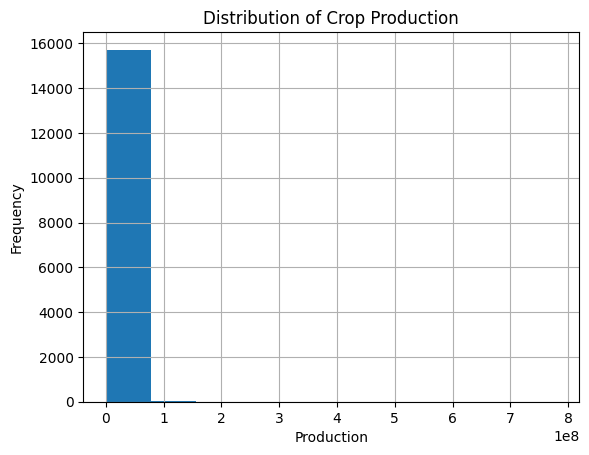

In [4]:
plt.figure()

data['Production'].hist()

plt.title("Distribution of Crop Production")
plt.xlabel("Production")
plt.ylabel("Frequency")

plt.show()

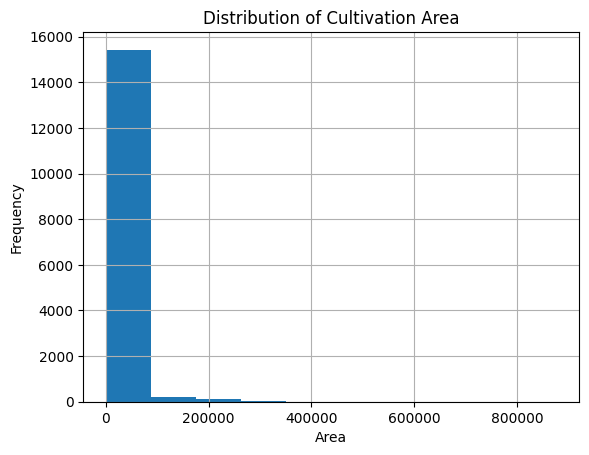

In [5]:
plt.figure()

data['Area'].hist()

plt.title("Distribution of Cultivation Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

In [6]:
data = data.dropna()

data = data[data['Area'] != 0]

data['Yield'] = data['Production'] / data['Area']

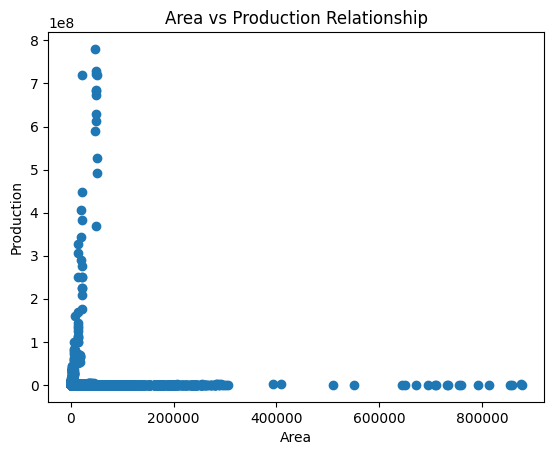

In [7]:
plt.figure()

plt.scatter(data['Area'], data['Production'])

plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production Relationship")

plt.show()

In [8]:
le = LabelEncoder()

data['State_Name'] = le.fit_transform(data['State_Name'])
data['District_Name'] = le.fit_transform(data['District_Name'])
data['Season'] = le.fit_transform(data['Season'])
data['Crop'] = le.fit_transform(data['Crop'])

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)

data['Cluster'] = kmeans.fit_predict(data[['Area','Production']])

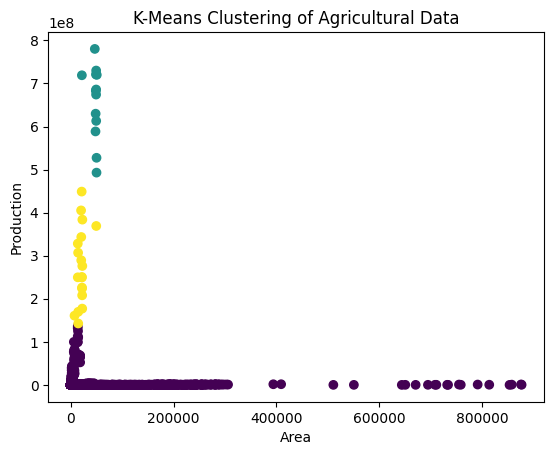

In [10]:
plt.figure()

plt.scatter(data['Area'], data['Production'], c=data['Cluster'])

plt.xlabel("Area")
plt.ylabel("Production")
plt.title("K-Means Clustering of Agricultural Data")

plt.show()

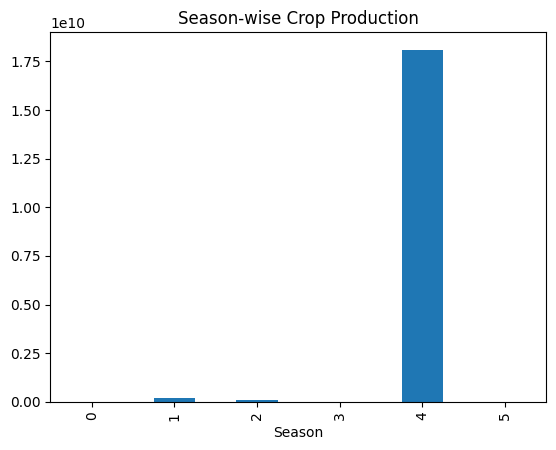

In [11]:
plt.figure()

data.groupby('Season')['Production'].sum().plot(kind='bar')

plt.title("Season-wise Crop Production")

plt.show()

In [12]:
X = data[['Crop','Season','Area','Cluster']]

y = data['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
predictions = model.predict(X_test)

print("Sample Predictions:")

print(predictions[:10])

Sample Predictions:
[ 3.74887443  1.46746154 14.71132484  0.28970899 71.6493017  13.359023
  0.52091399  4.47526085  1.06885899 32.75605209]


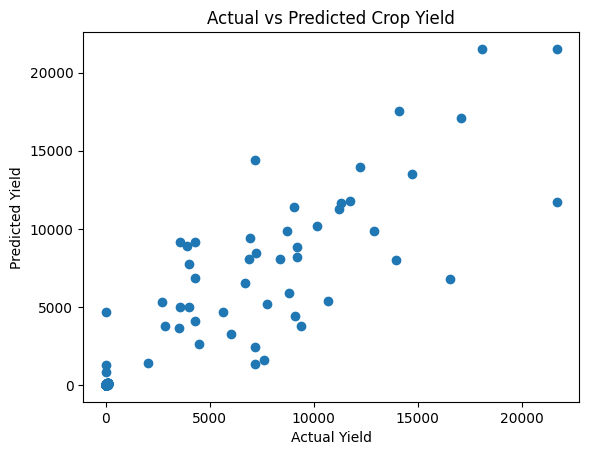

In [15]:
plt.figure()

plt.scatter(y_test, predictions)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

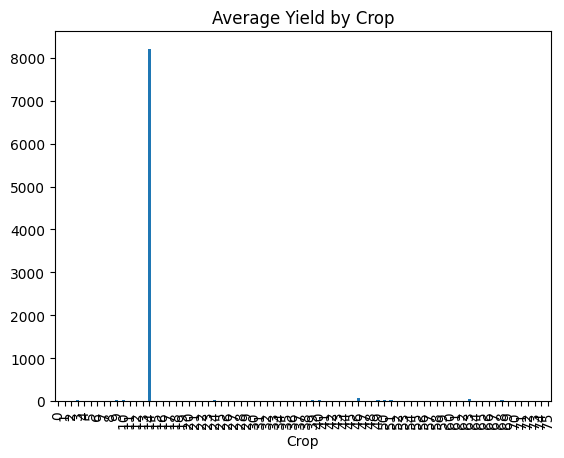

In [16]:
plt.figure()

data.groupby('Crop')['Yield'].mean().plot(kind='bar')

plt.title("Average Yield by Crop")

plt.show()